# Configuring PM++

{bdg-primary}`2 CUDA GPUs` {bdg-secondary}`256^3 baseline` {bdg-success}`saved outputs`

`Configuration` is a frozen JAX PyTree containing physical choices, numerical choices,
and derived arrays.  A change to a static field creates a new configuration and normally
causes JIT recompilation.  This notebook turns the most important relationships into
small, inspectable examples.

```{admonition} Committed execution record
:class: note
All outputs and plots on this page are committed in the notebook; hosted documentation
does not execute them.  The first executed output is the environment and configuration
record for the published run.
```


In [1]:
%matplotlib inline
from importlib.metadata import version as distribution_version
from pathlib import Path
import pmpp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pmpp.configuration import Configuration
from pmpp.multigpu_configuration import MultiGPUConfiguration
from pmpp.utils import create_compute_mesh

SEED = 0
RESOLUTION = 256
BOX_SIZE = 250.0
selected_devices = [device for device in jax.devices() if device.platform == "gpu"][:2]
if len(selected_devices) != 2:
    raise RuntimeError("This precomputed configuration notebook requires two visible CUDA devices.")
package_origin = (
    "site-packages"
    if any(part in {"site-packages", "dist-packages"} for part in Path(pmpp.__file__).resolve().parts)
    else "source-tree"
)
execution_record = {
    "pmpp_version": distribution_version("pmpp"),
    "package_origin": package_origin,
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "selected_device_count": len(selected_devices),
    "visible_device_count": len(jax.devices()),
    "selected_device_models": [device.device_kind for device in selected_devices],
    "seed": SEED,
    "configuration": {
        "box_size_mpc_h": BOX_SIZE,
        "particle_grid": (RESOLUTION,) * 3,
        "mesh_ratio": 1,
        "lpt_order": 2,
        "a_start": 1 / 64,
        "a_stop": 1.0,
        "a_nbody_maxstep": 1 / 64,
        "mode": "mesh_halo",
    },
    "capacities": {
        "max_ptcl_per_slice": 10_066_329,
        "max_share_ptcl": 1_600_000,
        "max_halo_share_ptcl": 800_000,
        "max_share_gather_ptcl": 1_800_000,
    },
}
print("PM++ DOCUMENTATION EXECUTION RECORD")
for key, value in execution_record.items():
    print(f"{key}: {value}")
compute_mesh = create_compute_mesh(selected_devices)

conf = Configuration(
    ptcl_spacing=BOX_SIZE / RESOLUTION,
    ptcl_grid_shape=(RESOLUTION,) * 3,
    mesh_shape=1,
    multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
    max_ptcl_per_slice=10_066_329,
    max_share_ptcl=1_600_000,
    max_halo_share_ptcl=800_000,
    max_share_gather_ptcl=1_800_000,
    lpt_order=2,
    a_start=1 / 64,
    a_stop=1.0,
    a_nbody_maxstep=1 / 64,
    float_dtype=jnp.float32,
)

geometry = {
    "box_size_mpc_h": conf.box_size,
    "particle_grid": conf.ptcl_grid_shape,
    "particle_spacing_mpc_h": conf.ptcl_spacing,
    "mesh_grid": conf.mesh_shape,
    "mesh_cell_mpc_h": conf.cell_size,
    "particles": conf.ptcl_num,
    "mesh_cells": conf.mesh_size,
}
geometry


PM++ DOCUMENTATION EXECUTION RECORD
pmpp_version: 0.1.6
package_origin: site-packages
jax_version: 0.6.2
backend: gpu
selected_device_count: 2
visible_device_count: 2
selected_device_models: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
seed: 0
configuration: {'box_size_mpc_h': 250.0, 'particle_grid': (256, 256, 256), 'mesh_ratio': 1, 'lpt_order': 2, 'a_start': 0.015625, 'a_stop': 1.0, 'a_nbody_maxstep': 0.015625, 'mode': 'mesh_halo'}
capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000}


{'box_size_mpc_h': (250.0, 250.0, 250.0),
 'particle_grid': (256, 256, 256),
 'particle_spacing_mpc_h': 0.9765625,
 'mesh_grid': (256, 256, 256),
 'mesh_cell_mpc_h': 0.9765625,
 'particles': 16777216,
 'mesh_cells': 16777216}

## Box, particles, and force mesh

For a cubic box of side $L$ and $N_p$ particles per axis,
$\Delta x_p=L/N_p$.  An integer `mesh_shape` is a ratio: `mesh_shape=2` creates a
$(2N_p)^3$ force mesh and halves the mesh-cell width.  The mesh may not be smaller than
the particle grid, and both grids must have the same aspect ratio.


In [2]:
rows = []
for resolution in (64, 128, 256):
    rows.append({
        "resolution": resolution,
        "particle_spacing": BOX_SIZE / resolution,
        "mesh_ratio_1": (resolution,) * 3,
        "mesh_ratio_2": (2 * resolution,) * 3,
        "particle_count": resolution**3,
    })
rows


[{'resolution': 64,
  'particle_spacing': 3.90625,
  'mesh_ratio_1': (64, 64, 64),
  'mesh_ratio_2': (128, 128, 128),
  'particle_count': 262144},
 {'resolution': 128,
  'particle_spacing': 1.953125,
  'mesh_ratio_1': (128, 128, 128),
  'mesh_ratio_2': (256, 256, 256),
  'particle_count': 2097152},
 {'resolution': 256,
  'particle_spacing': 0.9765625,
  'mesh_ratio_1': (256, 256, 256),
  'mesh_ratio_2': (512, 512, 512),
  'particle_count': 16777216}]

In [3]:
try:
    Configuration(
        ptcl_spacing=BOX_SIZE / RESOLUTION,
        ptcl_grid_shape=(256, 256, 256),
        mesh_shape=(512, 256, 512),
    )
except ValueError as exc:
    print(f"Expected incompatible-grid error: {exc}")


Expected incompatible-grid error: particle and mesh grid aspect ratios differ


## Time schedule and LPT order

`a_start`, `a_stop`, and `a_nbody_maxstep` determine a static integration schedule.
LPT orders 0, 1, and 2 are operational: order 0 starts from an unperturbed grid, order 1
is Zel'dovich, and order 2 includes the second-order tidal source.  Although the
configuration currently accepts order 3, `lpt(...)` raises `NotImplementedError`; do not
select it.


operational LPT orders: (0, 1, 2); selected: 2
N-body intervals: 63; actual step: 0.0156


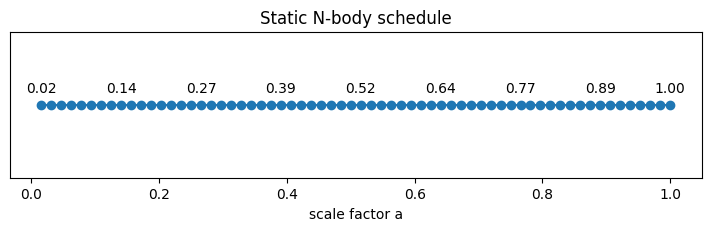

In [4]:
schedule = np.asarray(conf.a_nbody)
print(f"operational LPT orders: {tuple(range(3))}; selected: {conf.lpt_order}")
print(f"N-body intervals: {len(schedule) - 1}; actual step: {conf.a_nbody_step:.4f}")

fig, ax = plt.subplots(figsize=(7, 2.2), constrained_layout=True)
ax.plot(schedule, np.zeros_like(schedule), "o-")
for i, value in enumerate(schedule):
    if i % 8 == 0 or i == len(schedule) - 1:
        ax.annotate(f"{value:.2f}", (value, 0), xytext=(0, 9), textcoords="offset points", ha="center")
ax.set_yticks([])
ax.set_xlabel("scale factor a")
ax.set_title("Static N-body schedule")
plt.show()


## Dtypes, device mesh, and capacities

- `cosmo_dtype` controls cosmological tables; `float_dtype` controls particle and mesh
  fields; `pmid_dtype` stores integer mesh coordinates.
- The two-device JAX mesh fixes the slab topology used throughout this documentation;
  `mode="mesh_halo"` is the recommended distributed path.
- Static capacities are correctness limits.  Any overflow means truncation and invalidates
  the run; increase the named capacity and rerun.


In [5]:
runtime = {
    "frozen_configuration": conf.__dataclass_params__.frozen,
    "float_dtype": str(conf.float_dtype),
    "cosmo_dtype": str(conf.cosmo_dtype),
    "pmid_dtype": str(conf.pmid_dtype),
    "device_count": conf.num_devices,
    "mode": conf.multigpu_mode,
    "local_mesh_shape": conf.local_mesh_shape,
    "max_ptcl_per_slice": conf.max_ptcl_per_slice,
    "max_share_ptcl": conf.max_share_ptcl,
    "max_halo_share_ptcl": conf.max_halo_share_ptcl,
    "max_share_gather_ptcl": conf.max_share_gather_ptcl,
}
runtime


{'frozen_configuration': True,
 'float_dtype': 'float32',
 'cosmo_dtype': 'float64',
 'pmid_dtype': 'int16',
 'device_count': 2,
 'mode': 'mesh_halo',
 'local_mesh_shape': (128, 256, 256),
 'max_ptcl_per_slice': 10066329,
 'max_share_ptcl': 1600000,
 'max_halo_share_ptcl': 800000,
 'max_share_gather_ptcl': 1800000}

## Practical recompilation rule

Treat grid shapes, dtypes, LPT order, the scale-factor schedule, multi-GPU topology, and
capacities as compile-time choices.  Continuous array inputs (for example modes or
differentiable cosmology leaves) can vary without changing array shapes.  Build one
configuration, JIT one full callable, warm it once, and reuse it for comparable runs.
